# 03 — Lead-Lag Analysis

**Hypothesis:** Do DVOL spikes *precede* spot price moves, or only co-move?

Test three ways:
1. Cross-correlation function (CCF) at lags −48h to +48h
2. Granger causality test with Bonferroni correction
3. Two placebo tests to rule out spurious results

**Decision gate:** At least one signal definition must show p < 0.05 (Bonferroni-corrected) to proceed to backtesting.

In [1]:
import sys
sys.path.append('..')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.lead_lag import cross_correlation, granger_test, placebo_time_shuffle, placebo_random_jumps
from pathlib import Path

cfg = yaml.safe_load(open('../config.yaml'))
ll_cfg = cfg['lead_lag']
MAX_LAG = ll_cfg['max_lag_hours']
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
# Load signals and spot returns
sig_dir = Path('../data/signals')
crypto_dir = Path('../data/crypto')

btc_sigs = pd.read_parquet(sig_dir / 'BTC_signals.parquet')
eth_sigs = pd.read_parquet(sig_dir / 'ETH_signals.parquet')

btc_spot = pd.read_parquet(crypto_dir / 'BTCUSDT_1h.parquet')
eth_spot = pd.read_parquet(crypto_dir / 'ETHUSDT_1h.parquet')

btc_ret = np.log(btc_spot['close']).diff().rename('btc_ret')
eth_ret = np.log(eth_spot['close']).diff().rename('eth_ret')

print(f'BTC signals: {(btc_sigs != 0).any(axis=1).sum()} event bars')
print(f'ETH signals: {(eth_sigs != 0).any(axis=1).sum()} event bars')

BTC signals: 1375 event bars
ETH signals: 1359 event bars


## 1. Cross-Correlation Function (CCF)

Negative lag = signal fires *before* price move (what we want to find).

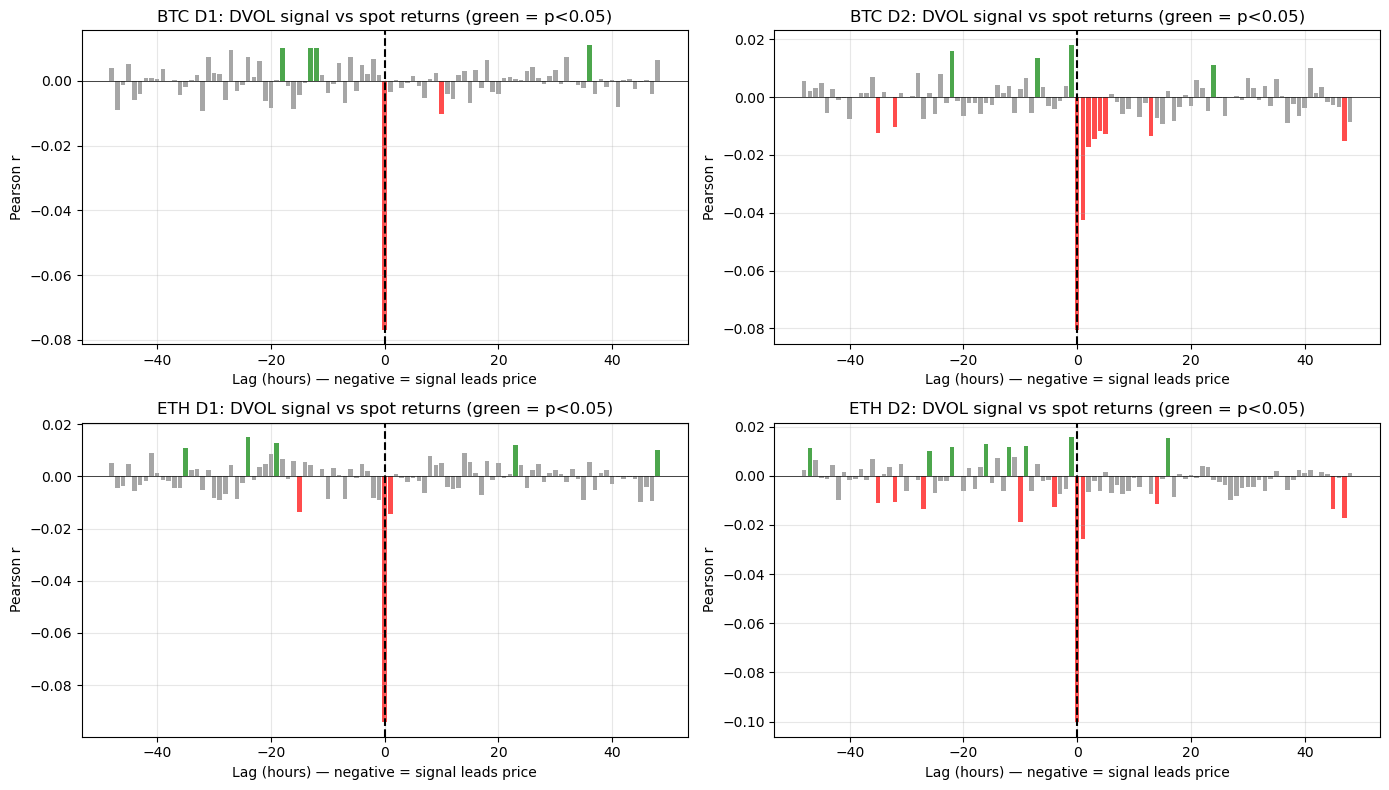

In [3]:
def plot_ccf(ccf_df: pd.DataFrame, title: str, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))
    colors = ['green' if (p < 0.05 and c > 0) else 'red' if (p < 0.05 and c < 0)
              else 'grey' for c, p in zip(ccf_df['correlation'], ccf_df['p_value'])]
    ax.bar(ccf_df.index, ccf_df['correlation'], color=colors, alpha=0.7, width=0.8)
    ax.axvline(0, color='black', lw=1.5, ls='--')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xlabel('Lag (hours) — negative = signal leads price')
    ax.set_ylabel('Pearson r')
    ax.set_title(title)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (sig_name, sigs, ret, ccy) in enumerate([
    ('D1', btc_sigs, btc_ret, 'BTC'),
    ('D2', btc_sigs, btc_ret, 'BTC'),
    ('D1', eth_sigs, eth_ret, 'ETH'),
    ('D2', eth_sigs, eth_ret, 'ETH'),
]):
    sig = sigs[sig_name]
    ccf = cross_correlation(sig, ret, max_lag=MAX_LAG)
    ax = axes[i // 2][i % 2]
    plot_ccf(ccf, f'{ccy} {sig_name}: DVOL signal vs spot returns (green = p<0.05)', ax)

plt.tight_layout()
plt.savefig('../data/plots/ccf_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Granger Causality Test

In [4]:
print('Running Granger causality tests (this takes ~1-2 minutes)...')

granger_results = {}
for sig_name in ['D1', 'D2']:
    for ccy, sigs, ret in [('BTC', btc_sigs, btc_ret), ('ETH', eth_sigs, eth_ret)]:
        key = f'{ccy}_{sig_name}'
        sig = sigs[sig_name].astype(float)
        result = granger_test(sig, ret, max_lags=ll_cfg['granger_max_lags'])
        granger_results[key] = result
        n_sig = result['significant'].sum()
        min_p = result['p_bonferroni'].min()
        print(f'  {key}: {n_sig} significant lags | min Bonferroni p = {min_p:.4f}')

print()
print('GATE: At least one definition needs p < 0.05 at some lag')

Running Granger causality tests (this takes ~1-2 minutes)...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


  BTC_D1: 0 significant lags | min Bonferroni p = 1.0000


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


  ETH_D1: 0 significant lags | min Bonferroni p = 0.1932


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


  BTC_D2: 1 significant lags | min Bonferroni p = 0.0301


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


  ETH_D2: 40 significant lags | min Bonferroni p = 0.0000

GATE: At least one definition needs p < 0.05 at some lag


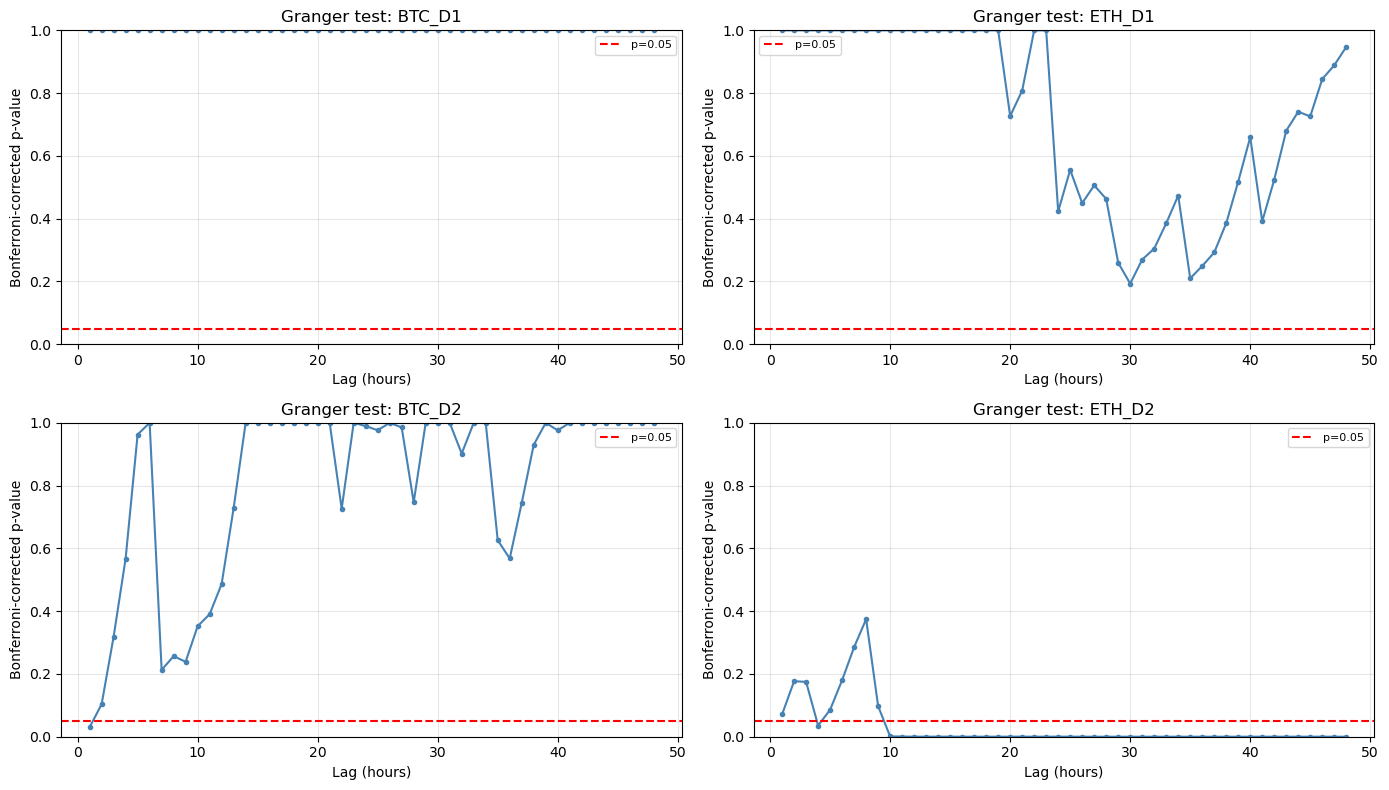

In [5]:
# Plot Granger p-values across lags
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (key, result) in enumerate(granger_results.items()):
    if i >= 4:
        break
    ax = axes[i // 2][i % 2]
    ax.plot(result.index, result['p_bonferroni'], color='steelblue', lw=1.5, marker='o', ms=3)
    ax.axhline(0.05, color='red', ls='--', lw=1.5, label='p=0.05')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Lag (hours)')
    ax.set_ylabel('Bonferroni-corrected p-value')
    ax.set_title(f'Granger test: {key}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/plots/granger_pvalues.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Placebo Tests

Two placebo tests rule out spurious results:
- **Time shuffle:** randomly scramble signal timestamps → should destroy any lead-lag structure
- **Random jumps:** replace real signals with random jumps at same frequency

In [6]:
print('Running placebo tests for BTC D1 (500 iterations each)...')

btc_d1 = btc_sigs['D1'].astype(float)
shuffle_result = placebo_time_shuffle(btc_d1, btc_ret, n_iter=500, max_lag=MAX_LAG)
random_result = placebo_random_jumps(btc_d1, btc_ret, n_iter=500, max_lag=MAX_LAG)

print(f"Time shuffle placebo: empirical p = {shuffle_result['empirical_p']:.4f}")
print(f"Random jumps placebo: empirical p = {random_result['empirical_p']:.4f}")
print()
print('If empirical p < 0.05: real signal is more predictive than random chance')

Running placebo tests for BTC D1 (500 iterations each)...


Time shuffle placebo: empirical p = 0.0000
Random jumps placebo: empirical p = 0.0000

If empirical p < 0.05: real signal is more predictive than random chance


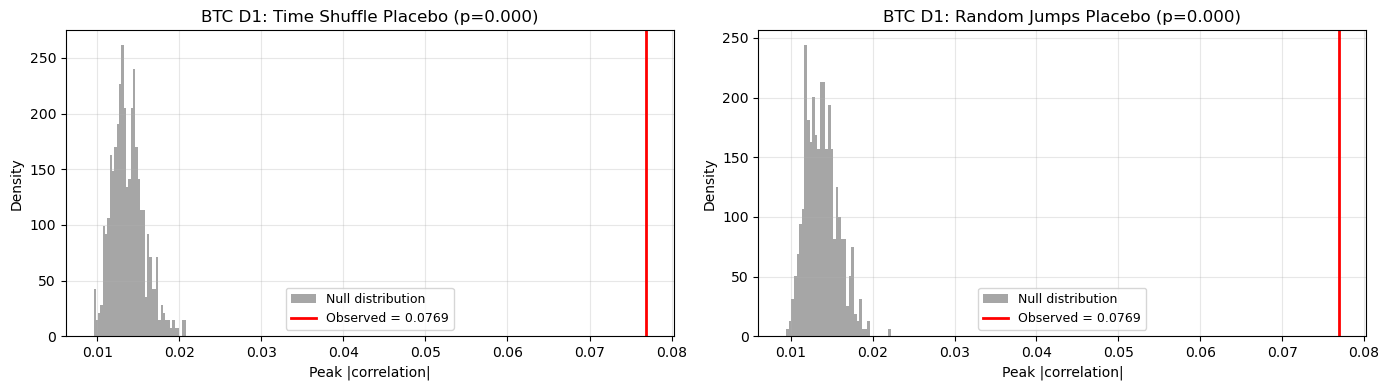

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, result, title in [
    (axes[0], shuffle_result, 'Time Shuffle Placebo'),
    (axes[1], random_result, 'Random Jumps Placebo')
]:
    ax.hist(result['null_peaks'], bins=40, color='grey', alpha=0.7, density=True, label='Null distribution')
    ax.axvline(result['observed_peak'], color='red', lw=2, label=f"Observed = {result['observed_peak']:.4f}")
    ax.set_xlabel('Peak |correlation|')
    ax.set_ylabel('Density')
    ax.set_title(f'BTC D1: {title} (p={result["empirical_p"]:.3f})')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/plots/placebos.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Decision Gate Summary

In [8]:
print('='*60)
print('LEAD-LAG ANALYSIS — DECISION GATE')
print('='*60)

gate_passed = False
for key, result in granger_results.items():
    min_p = result['p_bonferroni'].min()
    best_lag = result['p_bonferroni'].idxmin()
    passed = min_p < ll_cfg['significance_level']
    if passed:
        gate_passed = True
    status = '✓ PASS' if passed else '✗ FAIL'
    print(f'  {key}: min p={min_p:.4f} at lag {best_lag}h → {status}')

print()
if gate_passed:
    print('→ PROCEED to Notebook 04 (Event Study)')
else:
    print('→ HYPOTHESIS REJECTED: no significant lead-lag found. Stop here.')

LEAD-LAG ANALYSIS — DECISION GATE
  BTC_D1: min p=1.0000 at lag 1h → ✗ FAIL
  ETH_D1: min p=0.1932 at lag 30h → ✗ FAIL
  BTC_D2: min p=0.0301 at lag 1h → ✓ PASS
  ETH_D2: min p=0.0000 at lag 27h → ✓ PASS

→ PROCEED to Notebook 04 (Event Study)
